# Importação das bibliotecas básica

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

## Base de dados de crédito

In [2]:
df = pd.read_csv('../data/credit_data.csv')
df

,clientid,income,age,loan,default
0,1,66155.925095,59.017015,8106.532131,0
1,2,34415.153966,48.117153,6564.745018,0
2,3,57317.170063,63.108049,8020.953296,0
3,4,42709.534201,45.751972,6103.642260,0
4,5,66952.688845,18.584336,8770.099235,1
...,...,...,...,...,...
1995,1996,59221.044874,48.518179,1926.729397,0
1996,1997,69516.127573,23.162104,3503.176156,0
1997,1998,44311.449262,28.017167,5522.786693,1
1998,1999,43756.056605,63.971796,1622.722598,0


In [3]:
df.head(10)

,clientid,income,age,loan,default
0,1,66155.925095,59.017015,8106.532131,0
1,2,34415.153966,48.117153,6564.745018,0
2,3,57317.170063,63.108049,8020.953296,0
3,4,42709.534201,45.751972,6103.642260,0
4,5,66952.688845,18.584336,8770.099235,1
5,6,24904.064140,57.471607,15.498598,0
6,7,48430.359613,26.809132,5722.581981,0
7,8,24500.141984,32.897548,2971.003310,1
8,9,40654.892537,55.496853,4755.825280,0
9,10,25075.872771,39.776378,1409.230371,0


In [4]:
df.tail(10)

,clientid,income,age,loan,default
1990,1991,34237.575419,34.101654,2658.090632,0
1991,1992,26300.446554,45.539385,2317.393678,0
1992,1993,30803.806165,23.250084,623.024153,0
1993,1994,54421.410155,26.821928,3273.631823,0
1994,1995,24254.700791,37.751622,2225.284643,0
1995,1996,59221.044874,48.518179,1926.729397,0
1996,1997,69516.127573,23.162104,3503.176156,0
1997,1998,44311.449262,28.017167,5522.786693,1
1998,1999,43756.056605,63.971796,1622.722598,0
1999,2000,69436.579552,56.152617,7378.833599,0


In [5]:
df.describe()

,clientid,income,age,loan,default
count,2000.000000,2000.000000,1997.000000,2000.000000,2000.000000
mean,1000.500000,45331.600018,40.807559,4444.369695,0.141500
std,577.494589,14326.327119,13.624469,3045.410024,0.348624
min,1.000000,20014.489470,-52.423280,1.377630,0.000000
25%,500.750000,32796.459717,28.990415,1939.708847,0.000000
50%,1000.500000,45789.117313,41.317159,3974.719419,0.000000
75%,1500.250000,57791.281668,52.587040,6432.410625,0.000000
max,2000.000000,69995.685578,63.971796,13766.051239,1.000000


In [6]:
df[df['income'] >= 69995.685578]

,clientid,income,age,loan,default
422,423,69995.685578,52.719673,2084.370861,0


In [7]:
df[df['loan'] <= 1.377630]

,clientid,income,age,loan,default
865,866,28072.604355,54.142548,1.37763,0


## Visualização dos Dados

In [8]:
np.unique(df['default'], return_counts=True)

(array([0, 1]), array([1717,  283]))

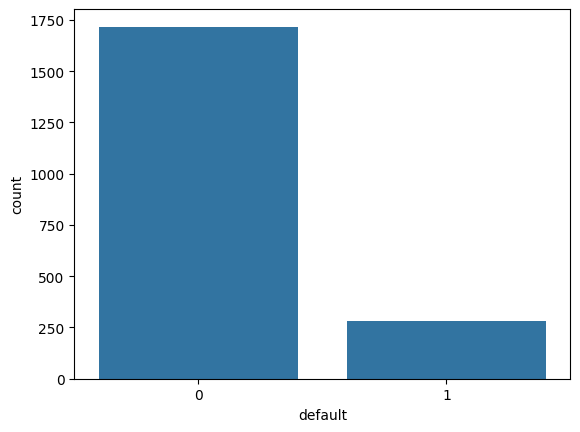

In [9]:
sns.countplot(x=df['default']);

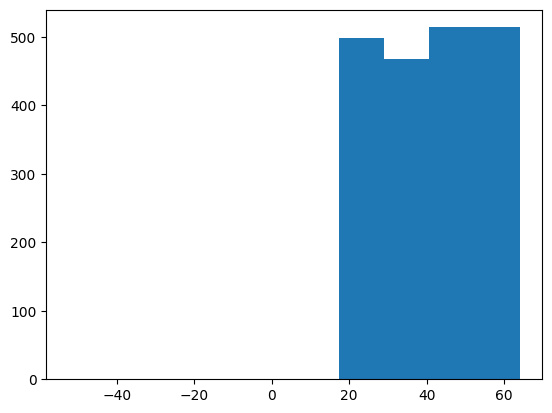

In [10]:
plt.hist(x=df['age']);

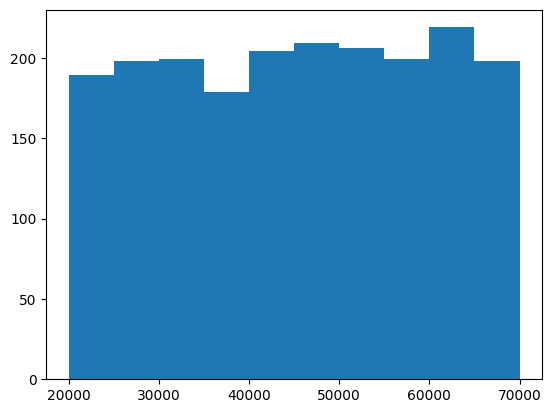

In [11]:
plt.hist(x=df['income']);

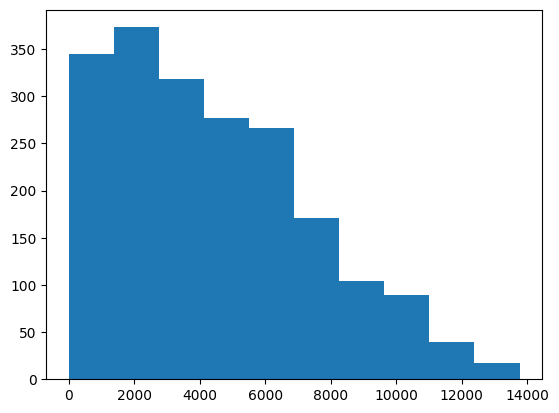

In [12]:
plt.hist(x=df['loan']);

In [13]:
grafico = px.scatter_matrix(df, dimensions=['age', 'income', 'loan'], color= 'default')
grafico.show()

## Tratamento de valores inconsistente

In [14]:
df.loc[df['age'] < 0]

,clientid,income,age,loan,default
15,16,50501.726689,-28.218361,3977.287432,0
21,22,32197.620701,-52.423280,4244.057136,0
26,27,63287.038908,-36.496976,9595.286289,0


In [15]:
df[df['age'] < 0]

,clientid,income,age,loan,default
15,16,50501.726689,-28.218361,3977.287432,0
21,22,32197.620701,-52.423280,4244.057136,0
26,27,63287.038908,-36.496976,9595.286289,0


In [16]:
# Apagando a coluna inteira
df2 = df.copy()
df2 = df2.drop('age', axis=1)
df2

,clientid,income,loan,default
0,1,66155.925095,8106.532131,0
1,2,34415.153966,6564.745018,0
2,3,57317.170063,8020.953296,0
3,4,42709.534201,6103.642260,0
4,5,66952.688845,8770.099235,1
...,...,...,...,...
1995,1996,59221.044874,1926.729397,0
1996,1997,69516.127573,3503.176156,0
1997,1998,44311.449262,5522.786693,1
1998,1999,43756.056605,1622.722598,0


In [17]:
# Apagando as linhas
df3 = df.copy()
df3 = df3.drop(df[df['age'] < 0].index)
df3

,clientid,income,age,loan,default
0,1,66155.925095,59.017015,8106.532131,0
1,2,34415.153966,48.117153,6564.745018,0
2,3,57317.170063,63.108049,8020.953296,0
3,4,42709.534201,45.751972,6103.642260,0
4,5,66952.688845,18.584336,8770.099235,1
...,...,...,...,...,...
1995,1996,59221.044874,48.518179,1926.729397,0
1996,1997,69516.127573,23.162104,3503.176156,0
1997,1998,44311.449262,28.017167,5522.786693,1
1998,1999,43756.056605,63.971796,1622.722598,0


In [18]:
df3[df3['age'] < 0]

,clientid,income,age,loan,default


In [19]:
# Preencher os valores inconsistente manualmente
df['age'][df['age'] > 0].mean()

np.float64(40.92770044906149)

In [20]:
df['age'] = df['age'].apply(lambda x: abs(x)) # transformando valores negativo para positivo
df[df['age'] < 0]

,clientid,income,age,loan,default


In [21]:
df.iloc[[15, 21, 26]]

,clientid,income,age,loan,default
15,16,50501.726689,28.218361,3977.287432,0
21,22,32197.620701,52.423280,4244.057136,0
26,27,63287.038908,36.496976,9595.286289,0


In [22]:
df['age'].mean()

np.float64(40.9248739670422)

## Tratamento de valores faltantes

In [23]:
df.isnull().sum()

clientid    0
income      0
age         3
loan        0
default     0
dtype: int64

In [24]:
df.loc[pd.isnull(df['age'])]

,clientid,income,age,loan,default
28,29,59417.805406,NaN,2082.625938,0
30,31,48528.852796,NaN,6155.784670,0
31,32,23526.302555,NaN,2862.010139,0


In [25]:
df.fillna({'age': df['age'].mean()}, inplace=True)
df.loc[pd.isnull(df['age'])]

,clientid,income,age,loan,default


In [26]:
df.loc[
    (df['clientid'] == 29) |
    (df['clientid'] == 31) |
    (df['clientid'] == 32)
]

,clientid,income,age,loan,default
28,29,59417.805406,40.924874,2082.625938,0
30,31,48528.852796,40.924874,6155.784670,0
31,32,23526.302555,40.924874,2862.010139,0


In [27]:
df.loc[df['clientid'].isin([29, 31, 32])]

,clientid,income,age,loan,default
28,29,59417.805406,40.924874,2082.625938,0
30,31,48528.852796,40.924874,6155.784670,0
31,32,23526.302555,40.924874,2862.010139,0


## Divisão entre previsores e classe

## Escalonamento dos valores